In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
from transformers import AutoTokenizer,AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
import seaborn as sns

In [ ]:
print(df_true.sample(1, random_state=42)["text"].values[0])

In [ ]:
fake=pd.read_csv('/Fake.csv')
true=pd.read_csv('/True.csv')

In [ ]:
fake.shape

(23481, 4)

In [ ]:
true.shape

(21417, 4)

In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [ ]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [ ]:
fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
fake["Label"]=0
true["Label"]=1

In [ ]:
df=pd.concat([fake,true],ignore_index=True)

In [ ]:
df=df.sample(frac=1,random_state=42)

In [ ]:
df.reset_index(drop=True,inplace=True)

In [ ]:
df.head()

,title,text,subject,date,Label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [ ]:
print(df.shape)

(44898, 5)


In [ ]:
print(df['Label'].value_counts())

Label
0    23481
1    21417
Name: count, dtype: int64


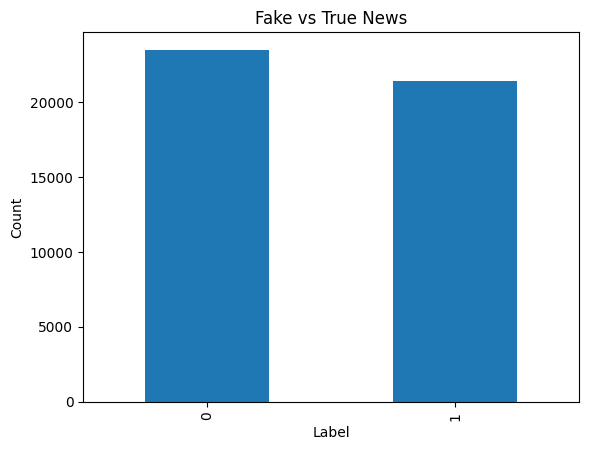

In [ ]:
df['Label'].value_counts().plot(kind="bar")
plt.title("Fake vs True News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [ ]:
df['content']=df['title']+" "+df['text']

In [ ]:
df[['content','Label']].head()

,content,Label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [ ]:
df=df[['content','Label']]

In [ ]:
df.head()

,content,Label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [ ]:
df.shape

(44898, 2)

In [ ]:
!pip install transformers -q

In [ ]:
tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
print(df['content'][0])

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Orde

In [ ]:
sample = tokenizer(df["content"][0])
print(sample)

{'input_ids': [101, 3841, 14233, 4455, 2041, 6280, 4984, 2457, 1024, 5462, 1037, 1520, 8648, 1040, 1521, 17997, 1521, 2114, 1996, 4552, 7398, 2301, 7318, 2758, 3841, 14233, 1010, 16360, 23056, 2934, 2013, 1010, 11565, 10672, 2118, 1006, 2036, 1997, 2070, 5365, 4476, 6037, 1999, 2694, 3065, 1998, 3152, 2107, 2004, 23202, 20934, 24038, 1055, 2154, 2125, 1007, 2081, 2070, 26422, 8635, 2006, 3648, 3744, 3170, 14255, 18933, 1055, 2265, 3728, 1012, 2096, 10537, 1996, 9190, 2008, 2001, 9770, 2006, 2343, 8398, 1055, 3237, 2344, 2006, 3604, 1012, 14233, 3615, 2000, 1996, 16646, 2011, 1996, 6280, 4984, 2457, 1999, 2899, 2110, 2004, 1037, 8648, 1040, 11937, 2102, 2114, 1996, 3237, 3589, 1998, 2114, 1996, 4552, 1012, 14233, 2253, 2006, 2000, 2655, 1996, 6794, 1999, 5862, 2576, 26101, 1998, 1996, 14814, 2576, 19175, 2015, 1012, 3422, 1996, 4357, 2917, 2005, 1996, 3143, 8635, 1998, 3602, 1996, 9762, 5688, 2000, 1996, 17871, 1997, 1996, 24247, 2865, 1998, 26136, 23194, 2015, 2040, 19046, 2000, 3602, 

In [ ]:
tokens = tokenizer.tokenize(df["content"][0])
print(tokens)

['ben', 'stein', 'calls', 'out', '9th', 'circuit', 'court', ':', 'committed', 'a', '‘', 'coup', 'd', '’', 'etat', '’', 'against', 'the', 'constitution', '21st', 'century', 'wire', 'says', 'ben', 'stein', ',', 'rep', '##utable', 'professor', 'from', ',', 'pepper', '##dine', 'university', '(', 'also', 'of', 'some', 'hollywood', 'fame', 'appearing', 'in', 'tv', 'shows', 'and', 'films', 'such', 'as', 'ferris', 'bu', '##eller', 's', 'day', 'off', ')', 'made', 'some', 'provocative', 'statements', 'on', 'judge', 'jean', '##ine', 'pi', '##rro', 's', 'show', 'recently', '.', 'while', 'discussing', 'the', 'halt', 'that', 'was', 'imposed', 'on', 'president', 'trump', 's', 'executive', 'order', 'on', 'travel', '.', 'stein', 'referred', 'to', 'the', 'judgement', 'by', 'the', '9th', 'circuit', 'court', 'in', 'washington', 'state', 'as', 'a', 'coup', 'd', 'ta', '##t', 'against', 'the', 'executive', 'branch', 'and', 'against', 'the', 'constitution', '.', 'stein', 'went', 'on', 'to', 'call', 'the', 'ju

In [ ]:
ids = tokenizer.convert_tokens_to_ids(tokens)
print(ids)

[3841, 14233, 4455, 2041, 6280, 4984, 2457, 1024, 5462, 1037, 1520, 8648, 1040, 1521, 17997, 1521, 2114, 1996, 4552, 7398, 2301, 7318, 2758, 3841, 14233, 1010, 16360, 23056, 2934, 2013, 1010, 11565, 10672, 2118, 1006, 2036, 1997, 2070, 5365, 4476, 6037, 1999, 2694, 3065, 1998, 3152, 2107, 2004, 23202, 20934, 24038, 1055, 2154, 2125, 1007, 2081, 2070, 26422, 8635, 2006, 3648, 3744, 3170, 14255, 18933, 1055, 2265, 3728, 1012, 2096, 10537, 1996, 9190, 2008, 2001, 9770, 2006, 2343, 8398, 1055, 3237, 2344, 2006, 3604, 1012, 14233, 3615, 2000, 1996, 16646, 2011, 1996, 6280, 4984, 2457, 1999, 2899, 2110, 2004, 1037, 8648, 1040, 11937, 2102, 2114, 1996, 3237, 3589, 1998, 2114, 1996, 4552, 1012, 14233, 2253, 2006, 2000, 2655, 1996, 6794, 1999, 5862, 2576, 26101, 1998, 1996, 14814, 2576, 19175, 2015, 1012, 3422, 1996, 4357, 2917, 2005, 1996, 3143, 8635, 1998, 3602, 1996, 9762, 5688, 2000, 1996, 17871, 1997, 1996, 24247, 2865, 1998, 26136, 23194, 2015, 2040, 19046, 2000, 3602, 2008, 2053, 2457, 2

In [ ]:
encoded = tokenizer(
    df["content"][0],
    padding="max_length",
    truncation=True,
    max_length=128)
print(encoded)

{'input_ids': [101, 3841, 14233, 4455, 2041, 6280, 4984, 2457, 1024, 5462, 1037, 1520, 8648, 1040, 1521, 17997, 1521, 2114, 1996, 4552, 7398, 2301, 7318, 2758, 3841, 14233, 1010, 16360, 23056, 2934, 2013, 1010, 11565, 10672, 2118, 1006, 2036, 1997, 2070, 5365, 4476, 6037, 1999, 2694, 3065, 1998, 3152, 2107, 2004, 23202, 20934, 24038, 1055, 2154, 2125, 1007, 2081, 2070, 26422, 8635, 2006, 3648, 3744, 3170, 14255, 18933, 1055, 2265, 3728, 1012, 2096, 10537, 1996, 9190, 2008, 2001, 9770, 2006, 2343, 8398, 1055, 3237, 2344, 2006, 3604, 1012, 14233, 3615, 2000, 1996, 16646, 2011, 1996, 6280, 4984, 2457, 1999, 2899, 2110, 2004, 1037, 8648, 1040, 11937, 2102, 2114, 1996, 3237, 3589, 1998, 2114, 1996, 4552, 1012, 14233, 2253, 2006, 2000, 2655, 1996, 6794, 1999, 5862, 2576, 26101, 1998, 1996, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
print(len(encoded["input_ids"]))

128


In [ ]:
X=df['content']
y=df['Label']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(35918,)
(8980,)
(35918,)
(8980,)


In [ ]:
train_encode=tokenizer(X_train.tolist(),truncation=True,padding="max_length",max_length=128)

In [ ]:
test_encode=tokenizer(X_test.tolist(),truncation=True,padding="max_length",max_length=128)

In [ ]:
print(train_encode['input_ids'][0])

[101, 3945, 4515, 2005, 4230, 1999, 3290, 2103, 2044, 8372, 3290, 2103, 1006, 26665, 1007, 1011, 1996, 3945, 2005, 5694, 1997, 2019, 8372, 2008, 2730, 5606, 1999, 3290, 2103, 3092, 2006, 9317, 2004, 5343, 3667, 6757, 1996, 2303, 1997, 1996, 2197, 2711, 2124, 2000, 2022, 4394, 4218, 1996, 17538, 1997, 7798, 3121, 1012, 4112, 4592, 2704, 10704, 3409, 2050, 2056, 2035, 1996, 4230, 2018, 2042, 6757, 2013, 1996, 8435, 1997, 2019, 2436, 2311, 1999, 1996, 28276, 12836, 2212, 1997, 1996, 3007, 1012, 1996, 3945, 2012, 2060, 3121, 2008, 7798, 3092, 2195, 2420, 3283, 1012, 1999, 2561, 4029, 2683, 2111, 2351, 1999, 1996, 17419, 1012, 2539, 8372, 1010, 1996, 2087, 9252, 1999, 1037, 4245, 1010, 2007, 2471, 2048, 1011, 12263, 1997, 1996, 20871, 1999, 1996, 3007, 1012, 3041, 102]


In [ ]:
print(train_encode['attention_mask'][0])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = NewsDataset(train_encode, y_train)

In [ ]:
test_dataset = NewsDataset(test_encode, y_test)

In [ ]:
print(len(train_dataset))
print(len(test_dataset))

35918
8980


In [ ]:
print(train_dataset[0])

{'input_ids': tensor([  101,  3945,  4515,  2005,  4230,  1999,  3290,  2103,  2044,  8372,
         3290,  2103,  1006, 26665,  1007,  1011,  1996,  3945,  2005,  5694,
         1997,  2019,  8372,  2008,  2730,  5606,  1999,  3290,  2103,  3092,
         2006,  9317,  2004,  5343,  3667,  6757,  1996,  2303,  1997,  1996,
         2197,  2711,  2124,  2000,  2022,  4394,  4218,  1996, 17538,  1997,
         7798,  3121,  1012,  4112,  4592,  2704, 10704,  3409,  2050,  2056,
         2035,  1996,  4230,  2018,  2042,  6757,  2013,  1996,  8435,  1997,
         2019,  2436,  2311,  1999,  1996, 28276, 12836,  2212,  1997,  1996,
         3007,  1012,  1996,  3945,  2012,  2060,  3121,  2008,  7798,  3092,
         2195,  2420,  3283,  1012,  1999,  2561,  4029,  2683,  2111,  2351,
         1999,  1996, 17419,  1012,  2539,  8372,  1010,  1996,  2087,  9252,
         1999,  1037,  4245,  1010,  2007,  2471,  2048,  1011, 12263,  1997,
         1996, 20871,  1999,  1996,  3007,  1012, 

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True)

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False)

In [ ]:
print(len(train_loader))
print(len(test_loader))

1123
281


In [ ]:
batch = next(iter(train_loader))

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
from torch.optim import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=2e-5)

In [ ]:
epochs = 3
model.train()
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    total_loss = 0
    for batch in train_loader:
      optimizer.zero_grad()
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)
      outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask,
          labels=labels)
      loss = outputs.loss
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
    print("Average Loss :", total_loss / len(train_loader))


Epoch 1/3
Average Loss : 0.014404032142009882

Epoch 2/3
Average Loss : 0.0023264164926962328

Epoch 3/3
Average Loss : 0.0018156324677321943


In [ ]:
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
predictions = []
true_labels = []

In [ ]:
with torch.no_grad():
  for batch in test_loader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask)
    logits = outputs.logits
    preds = torch.argmax(logits, dim=1)
    predictions.extend(preds.cpu().numpy())
    true_labels.extend(labels.cpu().numpy())

Accuracy : 0.9996659242761693
Precision : 1.0
Recall : 0.9992997198879552
F1 Score : 0.9996497373029772
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

[[4696    0]
 [   3 4281]]


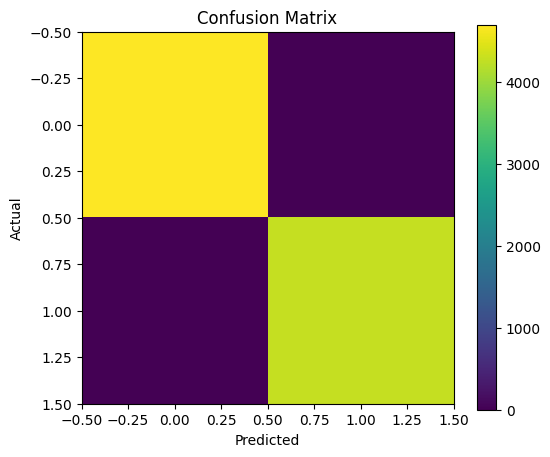

In [ ]:
accuracy = accuracy_score(true_labels,predictions)
print("Accuracy :", accuracy)
precision = precision_score(true_labels,predictions)
print("Precision :", precision)
recall = recall_score(true_labels,predictions)
print("Recall :", recall)
f1 = f1_score(true_labels,predictions)
print("F1 Score :", f1)
print(classification_report(true_labels,predictions))
cm = confusion_matrix(true_labels,predictions)
print(cm)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(predictions[:10])
print(true_labels[:10])

[np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(true_labels, predictions))
print("Error Count:", sum(p != t for p, t in zip(predictions, true_labels)))

Accuracy: 0.9996659242761693
Error Count: 3


In [ ]:
model.eval()

train_predictions = []
train_true_labels = []

with torch.no_grad():
    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        train_predictions.extend(preds.cpu().numpy())
        train_true_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(train_true_labels, train_predictions)
print("Training Accuracy :", train_acc)

Training Accuracy : 0.9999443176123393


In [ ]:
model.save_pretrained("bert_fake_news_model")
tokenizer.save_pretrained("bert_fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_fake_news_model/tokenizer_config.json',
 'bert_fake_news_model/tokenizer.json')

In [ ]:
import os
print(os.listdir("bert_fake_news_model"))

['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [ ]:
import shutil
shutil.make_archive(
    "bert_fake_news_model",
    "zip",
    "bert_fake_news_model")

'/content/bert_fake_news_model.zip'

In [ ]:
from google.colab import files
files.download("bert_fake_news_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loaded_tokenizer = AutoTokenizer.from_pretrained("bert_fake_news_model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("bert_fake_news_model")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
loaded_model.to(device)
loaded_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
def predict_news_loaded(news):
  encoding = loaded_tokenizer(news,truncation=True,padding="max_length",max_length=128,return_tensors="pt")
  input_ids = encoding["input_ids"].to(device)
  attention_mask = encoding["attention_mask"].to(device)
  with torch.no_grad():
    outputs = loaded_model(
        input_ids=input_ids,
        attention_mask=attention_mask)
    probabilities = torch.softmax(outputs.logits, dim=1)
    prediction = torch.argmax(probabilities, dim=1)
    confidence = torch.max(probabilities).item()
  if prediction.item() == 0:
    print("Fake News")
  else:
    print("True News")
  print(f"Confidence : {confidence*100:.2f}%")

In [ ]:
predict_news_loaded("""
NASA confirms that the Earth revolves around the Sun.
""")

Fake News
Confidence : 99.36%


In [ ]:
predict_news_loaded("""
The Reserve Bank of India announced a new monetary policy to control inflation after the latest meeting.
""")

Fake News
Confidence : 67.05%


In [ ]:
predict_news_loaded("""
Scientists discovered that drinking petrol cures every disease instantly.
""")

Fake News
Confidence : 99.15%


In [ ]:
print(df["Label"].value_counts())
print(df[["Label"]].head())

Label
0    23481
1    21417
Name: count, dtype: int64
   Label
0      0
1      1
2      1
3      0
4      1


In [ ]:
print(df[df["Label"]==0].iloc[0]["content"])
print("="*100)
print(df[df["Label"]==1].iloc[0]["content"])

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Orde

In [ ]:
test_news = [
    # TRUE NEWS
    "WASHINGTON (Reuters) - U.S. President Donald Trump met with congressional leaders at the White House on Tuesday to discuss tax reform and infrastructure spending.",

    "LONDON (Reuters) - Britain and the European Union resumed Brexit negotiations in Brussels on Monday, officials said.",

    "TOKYO (Reuters) - Japan's central bank kept its monetary policy unchanged after its latest meeting, citing stable economic growth.",

    "NEW YORK (Reuters) - The U.S. stock market closed higher on Friday after strong quarterly earnings from major technology companies.",

    "WASHINGTON (Reuters) - The Federal Reserve announced that interest rates would remain unchanged following its policy meeting.",


    # FAKE NEWS
    "Donald Trump officially announced that the Moon belongs to the United States and all countries must pay rent to use it.",

    "NASA confirmed that humans can survive without oxygen for three hours if they drink enough coffee.",

    "Scientists proved that drinking petrol every morning completely cures diabetes within one day.",

    "The White House declared that all citizens will receive one million dollars every month for life without paying taxes.",

    "Researchers discovered that eating only chocolate for one week can increase human intelligence by 500 percent."
]

print("="*100)

for i, news in enumerate(test_news, start=1):
    print(f"\nTest {i}")
    print("-"*100)
    print(news)
    print()

    predict_news_loaded(news)

print("="*100)


Test 1
----------------------------------------------------------------------------------------------------
WASHINGTON (Reuters) - U.S. President Donald Trump met with congressional leaders at the White House on Tuesday to discuss tax reform and infrastructure spending.

True News
Confidence : 100.00%

Test 2
----------------------------------------------------------------------------------------------------
LONDON (Reuters) - Britain and the European Union resumed Brexit negotiations in Brussels on Monday, officials said.

True News
Confidence : 100.00%

Test 3
----------------------------------------------------------------------------------------------------
TOKYO (Reuters) - Japan's central bank kept its monetary policy unchanged after its latest meeting, citing stable economic growth.

True News
Confidence : 100.00%

Test 4
----------------------------------------------------------------------------------------------------
NEW YORK (Reuters) - The U.S. stock market closed higher 